# **LEVEL 1**

Task: Data Exploration and Preprocessing

In [3]:
import pandas as pd


In [4]:
df=pd.read_csv("Dataset .csv")
print(df.sample(5))

      Restaurant ID      Restaurant Name  Country Code       City  \
6212         311379    Ganesh Restaurant             1  New Delhi   
932            9650      Cafe Coffee Day             1  Faridabad   
2765       18400737  Hangout Kathi Rolls             1  New Delhi   
812           71492           Ciclo Cafe             1    Chennai   
1222       18277179          Yum Yum Cha             1    Gurgaon   

                                                Address  \
6212  BG-8, DDA Central Market, Paschim Vihar, New D...   
932   SCF 42, Shopping Centre, Main Huda Market, Sec...   
2765  Shop 39/40, NDMC Market, Babar Road, Barakhamb...   
812      47, Gandhi Mandapam Road, Kotturpuram, Chennai   
1222                 Cyber Hub, DLF Cyber City, Gurgaon   

                       Locality                    Locality Verbose  \
6212              Paschim Vihar            Paschim Vihar, New Delhi   
932                   Sector 15                Sector 15, Faridabad   
2765            B

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df.shape

(9551, 21)

In [7]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

The dataset contains 9551 rows and 21 columns.
Most columns have complete data, except the Cuisines column which has 9 missing values.
These missing values were handled by replacing them with "Unknown" to maintain data consistency.

**Task :Descriptive Analysis**

In [8]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [9]:
# Handle missing
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Extract main cuisine
df['Main_Cuisine'] = df['Cuisines'].apply(lambda x: x.split(', ')[0])

# Encode
df['Main_Cuisine'] = df['Main_Cuisine'].astype('category').cat.codes

# Optional: number of cuisines
df['Num_Cuisines'] = df['Cuisines'].apply(lambda x: len(x.split(', ')))

# Drop original
df.drop('Cuisines', axis=1, inplace=True)

In [10]:
df.drop([
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose'
], axis=1, inplace=True)

In [11]:
binary_cols = [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [12]:
df["Rating text"].value_counts()

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

In [13]:
rating_map = {
    'Not rated': 0,
    'Poor': 1,
    'Average': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}

df['Rating text'] = df['Rating text'].map(rating_map)

The "Cuisines" column contained multi-label categorical data.
To avoid high dimensionality, the primary cuisine was extracted and encoded into a numerical format.
Additionally, the number of cuisines offered by each restaurant was calculated as a separate feature.
Irrelevant columns such as Restaurant ID, Name, and Address were removed as they do not contribute to predictive modeling.

In [14]:
# Keep only top 10 cities
top_cities = df['City'].value_counts().head(10).index

df['City_clean'] = df['City'].apply(
    lambda x: x if x in top_cities else 'Other'
)

# Encode
df['City_clean'] = df['City_clean'].astype('category').cat.codes

# Drop original
df.drop('City', axis=1, inplace=True)

In [15]:
df['Rating color']=df['Rating color'].astype('category').cat.codes

In [16]:
df['Currency'] = df['Currency'].astype('category').cat.codes

In [17]:
df['Aggregate rating'].value_counts()

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64

In [18]:
df = df[df['Aggregate rating'] > 0]

In [19]:
df.info()
df.sample(10)

<class 'pandas.core.frame.DataFrame'>
Index: 7403 entries, 0 to 9550
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          7403 non-null   int64  
 1   Longitude             7403 non-null   float64
 2   Latitude              7403 non-null   float64
 3   Average Cost for two  7403 non-null   int64  
 4   Currency              7403 non-null   int8   
 5   Has Table booking     7403 non-null   int64  
 6   Has Online delivery   7403 non-null   int64  
 7   Is delivering now     7403 non-null   int64  
 8   Switch to order menu  7403 non-null   int64  
 9   Price range           7403 non-null   int64  
 10  Aggregate rating      7403 non-null   float64
 11  Rating color          7403 non-null   int8   
 12  Rating text           7403 non-null   int64  
 13  Votes                 7403 non-null   int64  
 14  Main_Cuisine          7403 non-null   int8   
 15  Num_Cuisines          7403

,Country Code,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Main_Cuisine,Num_Cuisines,City_clean
6062,1,77.210454,28.642321,100,4,0,1,0,0,1,4.3,1,4,1317,105,1,8
5397,1,77.113684,28.724163,1000,4,0,0,0,0,3,2.8,2,2,83,54,3,8
6730,1,77.132292,28.734460,250,4,0,0,0,0,1,3.3,2,2,64,79,1,8
433,216,-157.831538,21.280663,10,2,0,0,0,0,1,4.0,1,4,535,19,1,10
964,1,77.318532,28.410659,400,4,0,0,0,0,1,3.1,2,2,26,79,1,3
1583,1,77.080235,28.481128,1800,4,1,0,0,0,3,2.1,3,1,90,30,3,5
6041,1,77.211337,28.645412,800,4,0,0,0,0,2,2.8,2,2,8,79,2,8
3807,1,77.205735,28.557792,1200,4,1,0,0,0,3,3.8,5,3,556,27,4,8
2052,1,77.044763,28.406486,550,4,0,1,0,0,2,3.3,2,2,175,12,3,5
3055,1,77.219813,28.630721,1000,4,0,0,0,0,3,3.7,5,3,3010,79,3,8


In [20]:
df.shape

(7403, 17)

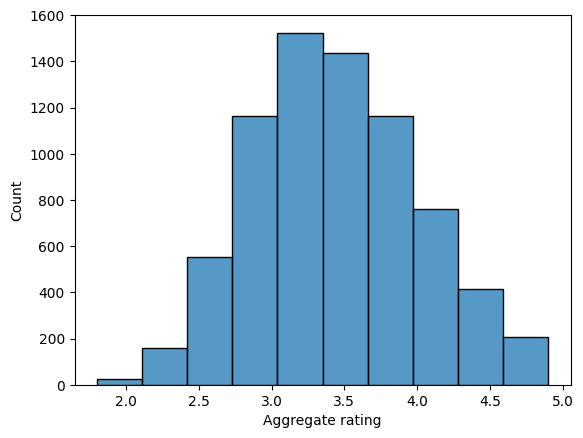

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Aggregate rating'], bins=10)
plt.show()

**Task: Geospatial Analysis**

In [22]:
import folium

# Center map at average location
m = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5
)

# Add markers (limit to avoid lag)
for i in range(min(1000, len(df))):
    folium.CircleMarker(
        location=[df.iloc[i]['Latitude'], df.iloc[i]['Longitude']],
        radius=3,
        popup=str(df.iloc[i]['Aggregate rating']),
        color='blue',
        fill=True
    ).add_to(m)
m


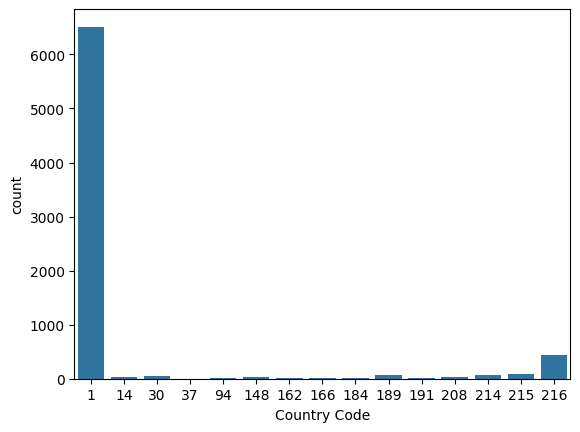

In [23]:
df['Country Code'].value_counts()
sns.countplot(x='Country Code', data=df)
plt.show()

In [24]:
df[['Latitude', 'Longitude', 'Aggregate rating']].corr()

,Latitude,Longitude,Aggregate rating
Latitude,1.000000,-0.097542,-0.179917
Longitude,-0.097542,1.000000,-0.291458
Aggregate rating,-0.179917,-0.291458,1.000000


The geospatial visualization shows that restaurants are highly concentrated in urban areas.
Major cities have a significantly higher number of restaurants compared to smaller regions.
Correlation analysis between location (latitude and longitude) and ratings indicates a weak relationship, suggesting that location alone does not strongly influence restaurant ratings

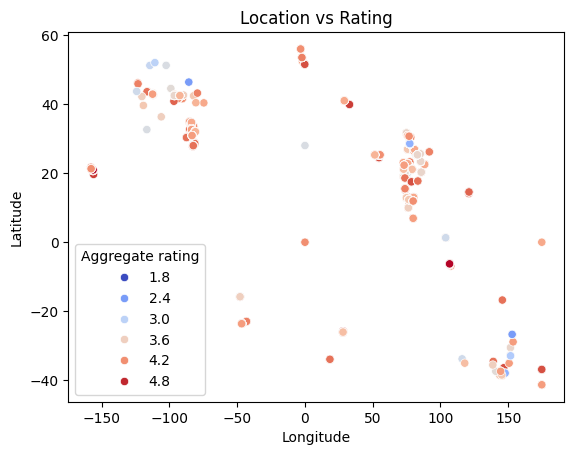

In [25]:
sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['Aggregate rating'],
    palette='coolwarm'
)
plt.title("Location vs Rating")
plt.show()

The dataset is heavily concentrated in urban cities.
There is a class imbalance in restaurant ratings.
Popular cuisines include North Indian and Chinese.
Location has limited direct impact on ratings.
Mid-range restaurants tend to perform better in terms of ratings.

# **LEVEL 3**

**Task: Predictive Modeling**

In [26]:
X=df.drop('Aggregate rating',axis=1)
y=df['Aggregate rating']

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

In [29]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)


In [31]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_test, y_pred, model_name):
    print(f"{model_name}:")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression:
MSE: 0.041701879455222565
R2 Score: 0.8651648628305543

Decision Tree:
MSE: 0.07239702903443618
R2 Score: 0.7659179042277905

Random Forest:
MSE: 0.03875327683997297
R2 Score: 0.8746986115075717



Three regression models were evaluated: Linear Regression, Decision Tree, and Random Forest.
Random Forest achieved the best performance with the lowest MSE (0.0387) and highest R² score (0.874), indicating strong predictive capability.
Linear Regression also performed well (R² ≈ 0.86), suggesting some linear relationships exist in the data.
Decision Tree showed lower performance due to overfitting and lack of generalization.


**Task: Customer Preference Analysis**

In [32]:
df.groupby('Main_Cuisine')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

Main_Cuisine
106    4.900000
96     4.700000
24     4.700000
108    4.650000
37     4.616667
85     4.600000
91     4.600000
119    4.500000
5      4.500000
46     4.480000
Name: Aggregate rating, dtype: float64

Certain cuisines tend to receive higher average ratings, indicating customer preference towards specific food types.

In [33]:
df.groupby('Main_Cuisine')['Votes'].sum().sort_values(ascending=False).head(10)

Main_Cuisine
79    356030
23    116504
2     105437
54     95145
30     94554
27     84744
35     45838
36     42441
12     41837
87     36373
Name: Votes, dtype: int64

Popular cuisines based on total votes , indicating higher customer engagement and demand.

In [34]:
# High rated cuisines
high_rated = df.groupby('Main_Cuisine')['Aggregate rating'].mean().sort_values(ascending=False)

# Most popular cuisines
popular = df.groupby('Main_Cuisine')['Votes'].sum().sort_values(ascending=False)

print(high_rated.head(5))
print(popular.head(5))

Main_Cuisine
106    4.900000
96     4.700000
24     4.700000
108    4.650000
37     4.616667
Name: Aggregate rating, dtype: float64
Main_Cuisine
79    356030
23    116504
2     105437
54     95145
30     94554
Name: Votes, dtype: int64


Some cuisines are highly popular but do not necessarily have the highest ratings, while others receive high ratings despite lower popularity. This indicates a difference between customer demand and perceived quality

**Task: Data Visualization**

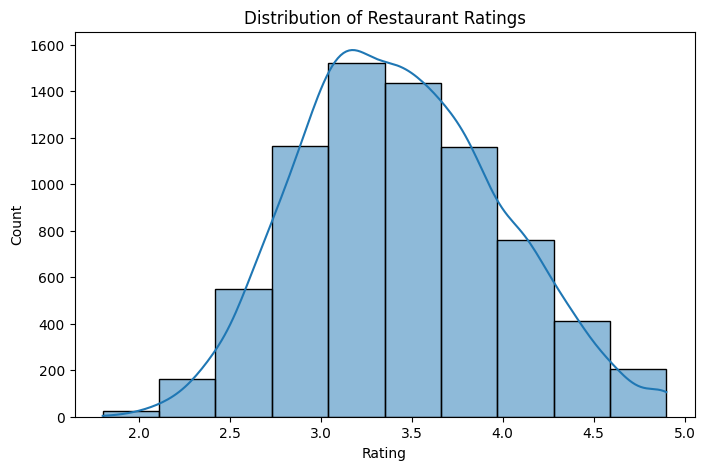

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=10, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

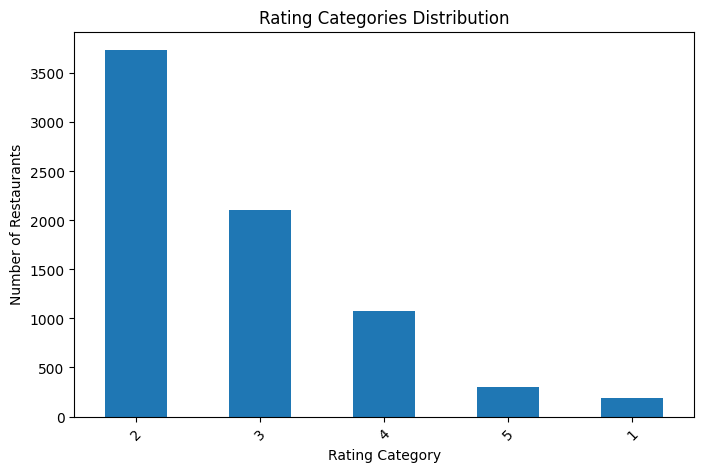

In [36]:
plt.figure(figsize=(8,5))
df['Rating text'].value_counts().plot(kind='bar')
plt.title("Rating Categories Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

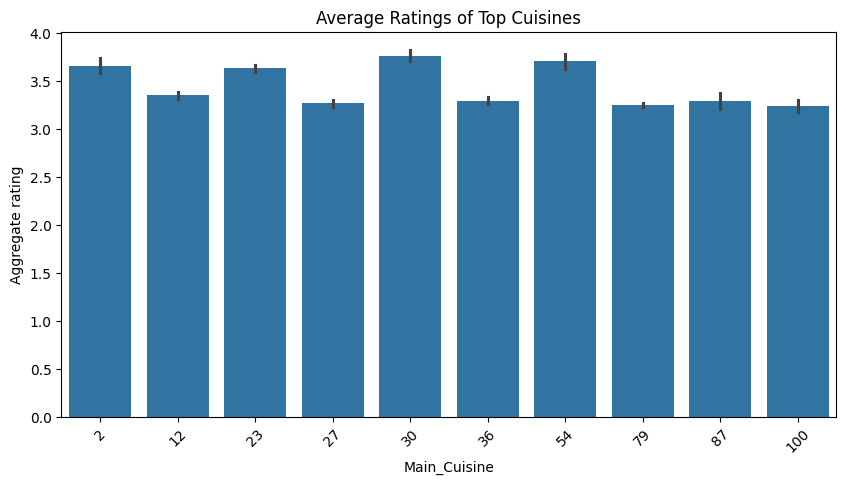

In [37]:
top_cuisines = df['Main_Cuisine'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.barplot(
    x='Main_Cuisine',
    y='Aggregate rating',
    data=df[df['Main_Cuisine'].isin(top_cuisines)]
)
plt.xticks(rotation=45)
plt.title("Average Ratings of Top Cuisines")
plt.show()

Some cuisines consistently receive higher ratings, suggesting strong customer satisfaction for those food types

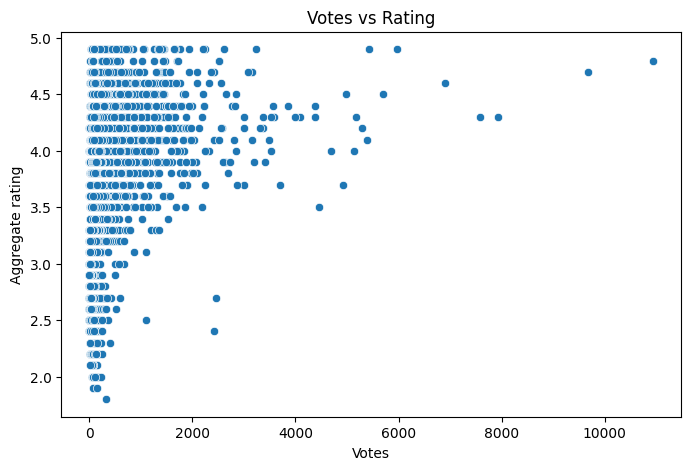

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Votes', y='Aggregate rating', data=df)
plt.title("Votes vs Rating")
plt.show()

A positive relationship is observed between the number of votes and ratings, suggesting that more popular restaurants tend to have higher ratings.

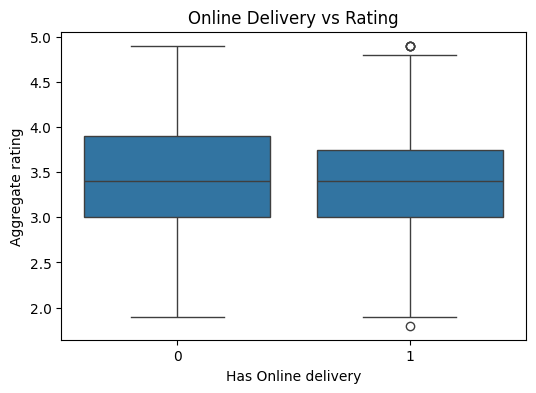

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df)
plt.title("Online Delivery vs Rating")
plt.show()